# Exercise Group (Monday, 08:15 - 09:45) - Chapter 4 (Part 02)

Below you find exercises for Chapter 4. The purpose of the prepared code snippets below is to give you some helpful structure for coding by predefining some useful variable names, but you do not need to use these prepared code snippets and prepared variable names if you do not want to. Do not hestitate to use the function `help()` to print the documentation of the functions that you need. If you are stuck, please ask one of the supervisors present.

<br>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import binom

companies = np.loadtxt('../shared_materials/data/DAX_companies.csv', skiprows=1, usecols=[1, 2, 3, 4, 5], delimiter=',')
log_returns = np.diff(np.log(companies), axis=0)

# Topic 4 - Estimating the Parameters of a Gaussian Copula with Kendall's $\tau$

In the file `DAX_companies.csv` you find a time series of the German stocks [BMW, SAP, Volkswagen, Continental, Siemens] between 03 January 2000 and 11 October 2024, making up for a total of $N = 6365$ data points. Our goal is to model the dependence structure of the logarithmic returns of these five companies using a Gaussian copula $C^{\mathrm{Ga}}_R$ and to estimate $R$ by the methods described in Section 4.3.5. Let $X_{n, i}$, $i \in \{1, \dots, 5\}$, denote the logarithmic returns series for these five companies. First, we would like to visualise the copula dependence of the BMW and SAP log-returns.

**Task 4.1**: For each $i \in \{1, \dots, 5\}$ compute the vector of transformed log-returns $(\widehat F_i(X_{n, i}))_{n \in \{1, \dots, N - 1\}}$, where $\widehat F_i$ denotes the empirical cdf of $(X_{n, i})_{n \in \{1, \dots, N - 1\}}$. Store the transformed returns in an array `transformed_returns` of the same shape as `log_returns`.

In [2]:
n = len(log_returns)

In [3]:
# Calculate empirical cdf's
emp_BMW = np.less_equal.outer(log_returns[:, 0], log_returns[:, 0]).mean(axis=0)
emp_SAP = np.less_equal.outer(log_returns[:, 1], log_returns[:, 1]).mean(axis=0)
emp_VW = np.less_equal.outer(log_returns[:, 2], log_returns[:, 2]).mean(axis=0)
# could take all values and append them together

In [4]:
emp_BMW

array([0.02686989, 0.11533627, 0.40210559, ..., 0.79006914, 0.29902577,
       0.21998743])

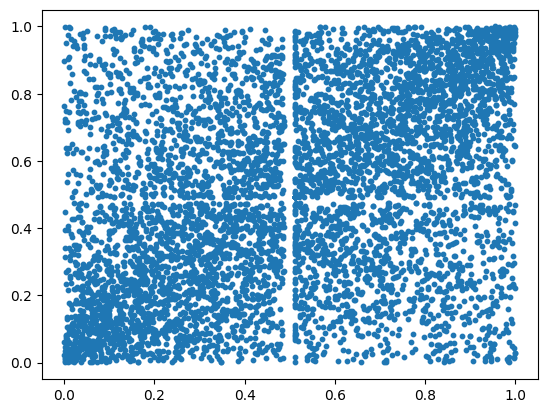

In [5]:
plt.scatter(emp_VW, emp_SAP, s=10)

In [6]:
# Pending --> compute the empirical quantiles

In [7]:
# For all returns
transformed_returns = np.less_equal.outer(log_returns, log_returns).mean(axis=0)
transformed_returns[0]

array([[2.68698931e-02, 1.57133878e-02, 1.94846009e-02, 5.02985544e-01,
        2.67127593e-02],
       [1.15336266e-01, 3.14267756e-04, 6.75675676e-01, 9.11219359e-01,
        4.14833438e-02],
       [4.02105594e-01, 9.52859837e-01, 8.93620365e-01, 8.34066625e-01,
        2.05059711e-01],
       ...,
       [7.90069139e-01, 8.13010685e-01, 7.53456945e-01, 9.96071653e-01,
        9.09962288e-01],
       [2.99025770e-01, 2.68698931e-01, 3.96291640e-01, 3.27938404e-01,
        3.29038341e-01],
       [2.19987429e-01, 7.91483344e-01, 3.46951603e-01, 6.92489001e-01,
        8.08610937e-01]])

In [8]:
# np.less_equal.outer(log_returns,log_returns).mean(axis=0)

**Task 4.2** Draw a scatter plot that plots the transformed returns of the BMW stock against the transformed returns of the SAP stock and interpret your result using a comment.

*Useful Python commands*: `plt.scatter`

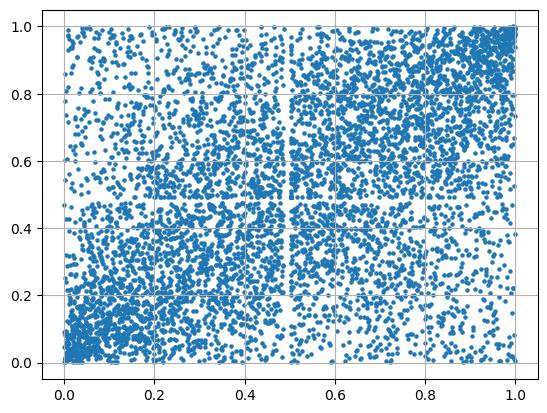

In [9]:
# Plot
plt.scatter(emp_BMW, emp_SAP, s=5)

plt.grid()
plt.show()

Now, we are ready to estimate the Gaussian copula $C^{\mathrm{Ga}}_R$ as in Section 4.3.5.

**Task 4.3**: For each $i, j \in \{1, \dots, 5\}$, $i \neq j$, compute Kendall's tau $\widehat \rho_\tau(X_{n, i}, X_{n, j})$ between the different companies using equation (4.1) in the lecture notes. Store these estimates in an array `kendall_tau` of shape `(5, 5)`.

*Useful Python commands*: `np.sign`. The binomial coefficent $\binom{n}{k}$ can be computed by the `scipy.special` command `binom(n, k)`.

In [10]:
# 1.Step: Get Kendals tau [Ref. 4.1.]
n = 5
k = 2

kendall_tau = np.zeros((5, 5)) #--> our desired shape

In [11]:
for k in range(1, n-1):
    for l in range(2, n):
        kendall_tau[k-1, l-2] = 1 / binom(n, 2) * np.sum(np.sign(("empiricals" - ((n+1)/2))("empiricals"- (n+1)/2))))

SyntaxError: unmatched ')' (3363536790.py, line 3)

**Task 4.4**: Compute the matrix $R \in \mathbb{R}^{2 \times 2}$ using the $\widehat \varrho_\tau$ estimates stored in the array `kendall_tau` by the method described in Section 4.3.5 and store it in an array `R` of shape `(5, 5)`. Afterwards, print `R` and interpret your result using a comment. Why are the diagonal elements of `R` not exactly equal to 1 even though $R$ is supposed to be a correlation matrix?

*Useful Python commands*: `np.sin`

In [ ]:
# Set up - datacontainer
R = np.zeros((5,5))

# Set up R matrix with kendall_tau
for i in range(0, 5):
    for j in range(0, 5):
        R[i, j] = np.sin(np.pi * (kendall_tau[i, j]) / 2)

In [ ]:
R